# Introducción a PySpark en Google Colab  
## Teoría + práctica guiada para entender cómo funciona Spark

Este notebook está pensado como una **introducción completa a PySpark** para alumnado que empieza a trabajar con procesamiento distribuido y Big Data.

La idea no es solo aprender comandos, sino entender **qué problema resuelve Spark**, **cómo organiza el trabajo**, y **qué partes principales tiene su API**.

---

## Qué vas a aprender

Al terminar este notebook deberías ser capaz de:

- entender qué es Apache Spark y por qué se usa
- diferenciar Spark de Pandas o Polars
- crear una sesión de Spark
- trabajar con **DataFrames**
- distinguir entre **transformaciones** y **acciones**
- entender la idea de **lazy evaluation**
- usar **Spark SQL**
- comprender qué son los **RDDs** y su relación con **MapReduce**
- ver una primera aproximación a **MLlib**
- entender el flujo mental con el que trabaja Spark

---

## Idea principal

Spark no está pensado solo para “hacer DataFrames más grandes”.

Spark está pensado para:
- repartir datos entre varias particiones
- procesarlos de manera eficiente
- construir un plan de ejecución
- optimizarlo
- ejecutarlo cuando realmente hace falta

Por eso, aprender Spark implica entender su **modelo mental**, no solo su sintaxis.

# 1. Preparación del entorno

En Colab necesitamos instalar PySpark.  
Ejecuta esta celda al principio.

In [ ]:
!pip -q install pyspark

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType, DoubleType
)

plt.rcParams["figure.figsize"] = (8, 4)
np.random.seed(42)

# 2. ¿Qué es Spark?

## Definición sencilla
Apache Spark es un motor de procesamiento de datos diseñado para trabajar de forma eficiente con grandes volúmenes de información.

## ¿Por qué no basta con Pandas?
Pandas funciona muy bien en memoria para análisis locales, pero cuando:
- los datos crecen mucho,
- el procesamiento se hace pesado,
- o el trabajo debe repartirse entre varias máquinas,

aparecen limitaciones.

## ¿Qué aporta Spark?
Spark aporta:
- **procesamiento distribuido**
- **ejecución optimizada**
- **trabajo en memoria**
- soporte para varias APIs:
  - DataFrame
  - SQL
  - RDD
  - MLlib
  - streaming

## Idea clave
Spark no ejecuta cada línea inmediatamente.  
Muchas veces **construye un plan** y lo lanza más tarde.  
Esa es una de las ideas más importantes de todo el notebook.

# 3. Crear la SparkSession

La **SparkSession** es el punto de entrada principal para trabajar con Spark.

Piensa en ella como:
- el objeto base desde el que arrancas Spark
- creas DataFrames
- ejecutas SQL
- y accedes al contexto general

En PySpark moderno, casi todo empieza aquí.

In [ ]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("Introduccion-PySpark-Colab")
    .getOrCreate()
)

spark

In [ ]:
print("Versión de Spark:", spark.version)
print("Spark listo")

Versión de Spark: 4.0.2
Spark listo


## ¿Qué significa `local[*]`?

Significa que Spark se ejecutará en local, usando todos los núcleos disponibles de la máquina.

Esto no es un clúster real, pero sirve perfectamente para:
- aprender
- practicar
- y entender el modelo de Spark

Más adelante, el mismo tipo de código puede ejecutarse sobre un clúster real.

# 4. Crear un dataset de ejemplo

Vamos a generar datos sintéticos para trabajar durante todo el notebook.

Tendremos una tabla de ventas con:
- ciudad
- categoría
- producto
- precio
- cantidad
- descuento
- puntuación

In [ ]:
n = 20000

pdf = pd.DataFrame({
    "sale_id": np.arange(1, n + 1),
    "city": np.random.choice(["Barcelona", "Madrid", "Valencia", "Sevilla", "Bilbao"], size=n),
    "category": np.random.choice(["Tecnologia", "Hogar", "Deporte", "Libros"], size=n),
    "product": np.random.choice(["A", "B", "C", "D", "E"], size=n),
    "price": np.round(np.random.uniform(10, 500, size=n), 2),
    "quantity": np.random.randint(1, 10, size=n),
    "discount": np.round(np.random.choice([0, 0.05, 0.10, 0.15, 0.20], size=n), 2),
    "rating": np.round(np.random.uniform(1, 5, size=n), 1)
})

pdf.head()

,sale_id,city,category,product,price,quantity,discount,rating
0,1,Sevilla,Libros,E,373.45,3,0.20,2.2
1,2,Bilbao,Hogar,A,275.25,2,0.10,2.1
2,3,Valencia,Tecnologia,E,52.11,6,0.10,2.5
3,4,Bilbao,Libros,B,23.14,8,0.15,1.5
4,5,Bilbao,Tecnologia,B,187.71,6,0.10,4.4


# 5. Crear un DataFrame de Spark

Podemos convertir un DataFrame de Pandas en un DataFrame de Spark.

Esto nos permite comparar mentalmente ambas herramientas.

## Ojo
Aunque ambos se llamen “DataFrame”, **no funcionan igual por dentro**.

In [ ]:
df = spark.createDataFrame(pdf)
df.show(5)

+-------+--------+----------+-------+------+--------+--------+------+
|sale_id|    city|  category|product| price|quantity|discount|rating|
+-------+--------+----------+-------+------+--------+--------+------+
|      1| Sevilla|    Libros|      E|373.45|       3|     0.2|   2.2|
|      2|  Bilbao|     Hogar|      A|275.25|       2|     0.1|   2.1|
|      3|Valencia|Tecnologia|      E| 52.11|       6|     0.1|   2.5|
|      4|  Bilbao|    Libros|      B| 23.14|       8|    0.15|   1.5|
|      5|  Bilbao|Tecnologia|      B|187.71|       6|     0.1|   4.4|
+-------+--------+----------+-------+------+--------+--------+------+
only showing top 5 rows


In [ ]:
df.printSchema()

root
 |-- sale_id: long (nullable = true)
 |-- city: string (nullable = true)
 |-- category: string (nullable = true)
 |-- product: string (nullable = true)
 |-- price: double (nullable = true)
 |-- quantity: long (nullable = true)
 |-- discount: double (nullable = true)
 |-- rating: double (nullable = true)



## Qué observamos

Con `printSchema()` vemos el esquema:
- nombres de columnas
- tipos de datos
- y estructura del DataFrame

Esto en Spark es muy importante porque el motor necesita conocer la estructura para planificar la ejecución.

# 6. Primeras operaciones con DataFrames

## 6.1 Selección de columnas

In [ ]:
df.select("city", "category", "price").show(5)

+--------+----------+------+
|    city|  category| price|
+--------+----------+------+
| Sevilla|    Libros|373.45|
|  Bilbao|     Hogar|275.25|
|Valencia|Tecnologia| 52.11|
|  Bilbao|    Libros| 23.14|
|  Bilbao|Tecnologia|187.71|
+--------+----------+------+
only showing top 5 rows


## 6.2 Filtrado

In [ ]:
df.filter((F.col("city") == "Barcelona") & (F.col("price") > 200)).show(5)

+-------+---------+----------+-------+------+--------+--------+------+
|sale_id|     city|  category|product| price|quantity|discount|rating|
+-------+---------+----------+-------+------+--------+--------+------+
|     19|Barcelona|Tecnologia|      A|496.56|       9|     0.1|   1.0|
|     24|Barcelona|     Hogar|      C|458.14|       4|    0.05|   2.2|
|     34|Barcelona|    Libros|      E|468.42|       8|     0.0|   2.1|
|     39|Barcelona|   Deporte|      C|343.13|       6|     0.0|   3.7|
|     46|Barcelona|Tecnologia|      D|459.27|       4|     0.0|   3.1|
+-------+---------+----------+-------+------+--------+--------+------+
only showing top 5 rows


## 6.3 Ordenación

In [ ]:
df.orderBy(F.col("price").desc()).show(5)

+-------+---------+----------+-------+------+--------+--------+------+
|sale_id|     city|  category|product| price|quantity|discount|rating|
+-------+---------+----------+-------+------+--------+--------+------+
|   1557| Valencia|   Deporte|      B|499.99|       6|    0.05|   2.7|
|   4743| Valencia|    Libros|      A|499.98|       6|     0.1|   2.1|
|  16113|Barcelona|     Hogar|      A|499.97|       7|     0.1|   1.7|
|   9435|   Madrid|     Hogar|      E|499.92|       2|     0.0|   3.6|
|   4008|  Sevilla|Tecnologia|      E|499.91|       1|     0.0|   4.4|
+-------+---------+----------+-------+------+--------+--------+------+
only showing top 5 rows


## 6.4 Nueva columna

Vamos a crear:
- `gross_total = price * quantity`
- `net_total = gross_total * (1 - discount)`

In [ ]:
df_calc = (
    df.withColumn("gross_total", F.col("price") * F.col("quantity"))
      .withColumn("net_total", F.col("gross_total") * (1 - F.col("discount")))
)

df_calc.show(5)

+-------+--------+----------+-------+------+--------+--------+------+------------------+---------+
|sale_id|    city|  category|product| price|quantity|discount|rating|       gross_total|net_total|
+-------+--------+----------+-------+------+--------+--------+------+------------------+---------+
|      1| Sevilla|    Libros|      E|373.45|       3|     0.2|   2.2|           1120.35|   896.28|
|      2|  Bilbao|     Hogar|      A|275.25|       2|     0.1|   2.1|             550.5|   495.45|
|      3|Valencia|Tecnologia|      E| 52.11|       6|     0.1|   2.5|312.65999999999997|  281.394|
|      4|  Bilbao|    Libros|      B| 23.14|       8|    0.15|   1.5|            185.12|  157.352|
|      5|  Bilbao|Tecnologia|      B|187.71|       6|     0.1|   4.4|           1126.26| 1013.634|
+-------+--------+----------+-------+------+--------+--------+------+------------------+---------+
only showing top 5 rows


# 7. Transformaciones vs acciones

Esta es una de las ideas más importantes de Spark.

## Transformaciones
Son operaciones que **definen trabajo**, pero normalmente no lo ejecutan todavía.

Ejemplos:
- `select`
- `filter`
- `withColumn`
- `groupBy`
- `orderBy`

## Acciones
Son operaciones que **obligan a Spark a ejecutar** el plan.

Ejemplos:
- `show`
- `count`
- `collect`
- `take`
- `first`

## Idea clave
Spark intenta retrasar la ejecución para:
- optimizar el plan
- combinar pasos
- minimizar trabajo innecesario

Esto se parece a la idea de lazy execution que ya has visto en Polars.

In [ ]:
# Transformación: todavía no vemos resultado real
df_barcelona = df.filter(F.col("city") == "Barcelona")

type(df_barcelona)

pyspark.sql.classic.dataframe.DataFrame

In [ ]:
# Acción: aquí Spark ejecuta el trabajo
df_barcelona.count()

4041

## Cómo pensarlo

Cuando escribes una transformación, no le estás diciendo a Spark:
> “hazlo ya”

Le estás diciendo:
> “apunta que luego quiero esto”

Y cuando llamas a una acción, Spark entiende:
> “ahora sí, ejecútalo”

# 8. Lazy evaluation

## ¿Qué significa?

Spark no ejecuta inmediatamente cada transformación.  
Va construyendo internamente un **DAG** (grafo de ejecución) con los pasos necesarios.

Después, cuando aparece una acción:
- analiza el plan
- lo optimiza
- y entonces lo ejecuta

## ¿Por qué es útil?
Porque así puede:
- eliminar pasos redundantes
- reordenar algunas operaciones
- reducir movimiento de datos
- y aprovechar mejor los recursos

In [ ]:
plan_df = (
    df.filter(F.col("price") > 100)
      .select("city", "category", "price", "quantity")
      .withColumn("gross_total", F.col("price") * F.col("quantity"))
      .groupBy("city", "category")
      .agg(F.avg("gross_total").alias("avg_gross_total"))
)

plan_df

DataFrame[city: string, category: string, avg_gross_total: double]

In [ ]:
# Ver el plan lógico y físico
plan_df.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[city#1, category#2], functions=[avg(gross_total#138)])
   +- Exchange hashpartitioning(city#1, category#2, 200), ENSURE_REQUIREMENTS, [plan_id=123]
      +- HashAggregate(keys=[city#1, category#2], functions=[partial_avg(gross_total#138)])
         +- Project [city#1, category#2, (price#4 * cast(quantity#5L as double)) AS gross_total#138]
            +- Filter (isnotnull(price#4) AND (price#4 > 100.0))
               +- Scan ExistingRDD[sale_id#0L,city#1,category#2,product#3,price#4,quantity#5L,discount#6,rating#7]




## Qué significa `explain()`

`explain()` nos deja ver cómo interpreta Spark la consulta.

No hace falta memorizar todos los detalles del plan, pero sí entender que Spark:
- no ejecuta línea a línea como una calculadora simple
- sino que construye y optimiza un flujo completo

# 9. Agrupaciones y agregaciones

Las agregaciones son muy comunes en Spark.

Vamos a calcular:
- número de ventas
- precio medio
- cantidad total
- venta máxima

por ciudad y categoría.

In [ ]:
grouped = (
    df.groupBy("city", "category")
      .agg(
          F.count("*").alias("num_sales"),
          F.avg("price").alias("avg_price"),
          F.sum("quantity").alias("total_quantity"),
          F.max("price").alias("max_price")
      )
      .orderBy(F.col("num_sales").desc())
)

grouped.show(20)

+---------+----------+---------+------------------+--------------+---------+
|     city|  category|num_sales|         avg_price|total_quantity|max_price|
+---------+----------+---------+------------------+--------------+---------+
|   Bilbao|   Deporte|     1045|261.76979904306245|          5120|   499.47|
|   Madrid|   Deporte|     1042| 261.8640882917469|          5292|   499.25|
|   Madrid|Tecnologia|     1037|252.28334619093548|          5257|   499.22|
|   Madrid|    Libros|     1037| 255.1677531340405|          5133|   499.71|
|  Sevilla|     Hogar|     1029|255.56667638483958|          4974|   499.78|
|   Bilbao|    Libros|     1023|256.54929618768324|          5000|   499.89|
|Barcelona|Tecnologia|     1019|253.25167811579965|          5054|   498.25|
|Barcelona|   Deporte|     1018| 257.5523673870333|          4947|   497.61|
|Barcelona|    Libros|     1016| 256.9327066929133|          5017|   499.73|
| Valencia|Tecnologia|     1003| 254.6116650049851|          5086|   499.85|

# 10. Valores nulos

En datos reales, casi siempre habrá nulos.

Vamos a crear algunos y practicar.

In [ ]:
pdf_nulls = pdf.copy()

idx = np.random.choice(pdf_nulls.index, size=500, replace=False)
pdf_nulls.loc[idx[:150], "city"] = None
pdf_nulls.loc[idx[150:300], "discount"] = None
pdf_nulls.loc[idx[300:], "rating"] = None

df_nulls = spark.createDataFrame(pdf_nulls)
df_nulls.show(5)

+-------+--------+----------+-------+------+--------+--------+------+
|sale_id|    city|  category|product| price|quantity|discount|rating|
+-------+--------+----------+-------+------+--------+--------+------+
|      1| Sevilla|    Libros|      E|373.45|       3|     0.2|   2.2|
|      2|  Bilbao|     Hogar|      A|275.25|       2|     0.1|   2.1|
|      3|Valencia|Tecnologia|      E| 52.11|       6|     0.1|   2.5|
|      4|  Bilbao|    Libros|      B| 23.14|       8|    0.15|   1.5|
|      5|  Bilbao|Tecnologia|      B|187.71|       6|     0.1|   4.4|
+-------+--------+----------+-------+------+--------+--------+------+
only showing top 5 rows


In [ ]:
df_nulls.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_nulls.columns
]).show()

+-------+----+--------+-------+-----+--------+--------+------+
|sale_id|city|category|product|price|quantity|discount|rating|
+-------+----+--------+-------+-----+--------+--------+------+
|      0| 150|       0|      0|    0|       0|       0|     0|
+-------+----+--------+-------+-----+--------+--------+------+



In [ ]:
df_filled = df_nulls.fillna({
    "city": "Desconocida",
    "discount": 0.0,
    "rating": 0.0
})

df_filled.show(5)

+-------+--------+----------+-------+------+--------+--------+------+
|sale_id|    city|  category|product| price|quantity|discount|rating|
+-------+--------+----------+-------+------+--------+--------+------+
|      1| Sevilla|    Libros|      E|373.45|       3|     0.2|   2.2|
|      2|  Bilbao|     Hogar|      A|275.25|       2|     0.1|   2.1|
|      3|Valencia|Tecnologia|      E| 52.11|       6|     0.1|   2.5|
|      4|  Bilbao|    Libros|      B| 23.14|       8|    0.15|   1.5|
|      5|  Bilbao|Tecnologia|      B|187.71|       6|     0.1|   4.4|
+-------+--------+----------+-------+------+--------+--------+------+
only showing top 5 rows


# 11. Joins en Spark

Los joins son fundamentales para integrar datos.

Vamos a crear una segunda tabla con información sobre categorías.

In [ ]:
schema_cat = StructType([
    StructField("category", StringType(), True),
    StructField("vat", DoubleType(), True),
    StructField("fragile", StringType(), True)
])

cat_data = [
    ("Tecnologia", 0.21, "si"),
    ("Hogar", 0.10, "si"),
    ("Deporte", 0.21, "no"),
    ("Libros", 0.04, "no")
]

df_cat = spark.createDataFrame(cat_data, schema=schema_cat)
df_cat.show()

+----------+----+-------+
|  category| vat|fragile|
+----------+----+-------+
|Tecnologia|0.21|     si|
|     Hogar| 0.1|     si|
|   Deporte|0.21|     no|
|    Libros|0.04|     no|
+----------+----+-------+



In [ ]:
df_join = df.join(df_cat, on="category", how="left")
df_join.show(5)

+----------+-------+--------+-------+------+--------+--------+------+----+-------+
|  category|sale_id|    city|product| price|quantity|discount|rating| vat|fragile|
+----------+-------+--------+-------+------+--------+--------+------+----+-------+
|    Libros|      1| Sevilla|      E|373.45|       3|     0.2|   2.2|0.04|     no|
|    Libros|      4|  Bilbao|      B| 23.14|       8|    0.15|   1.5|0.04|     no|
|Tecnologia|      3|Valencia|      E| 52.11|       6|     0.1|   2.5|0.21|     si|
|Tecnologia|      5|  Bilbao|      B|187.71|       6|     0.1|   4.4|0.21|     si|
|Tecnologia|      6|  Madrid|      E|403.09|       4|    0.05|   4.0|0.21|     si|
+----------+-------+--------+-------+------+--------+--------+------+----+-------+
only showing top 5 rows


## Tipos de join más comunes
- `inner`
- `left`
- `right`
- `outer`

La lógica general es la misma que en SQL y en Pandas, pero Spark lo ejecuta de manera distribuida.

# 12. Columnas derivadas y expresiones

Spark trabaja mucho con expresiones sobre columnas.

Vamos a crear:
- un nivel de precio
- y una etiqueta de venta grande o pequeña

In [ ]:
df_labels = (
    df.withColumn(
        "price_level",
        F.when(F.col("price") < 100, "bajo")
         .when(F.col("price") < 300, "medio")
         .otherwise("alto")
    )
    .withColumn(
        "big_sale",
        F.when(F.col("quantity") >= 7, "si").otherwise("no")
    )
)

df_labels.show(10)

+-------+--------+----------+-------+------+--------+--------+------+-----------+--------+
|sale_id|    city|  category|product| price|quantity|discount|rating|price_level|big_sale|
+-------+--------+----------+-------+------+--------+--------+------+-----------+--------+
|      1| Sevilla|    Libros|      E|373.45|       3|     0.2|   2.2|       alto|      no|
|      2|  Bilbao|     Hogar|      A|275.25|       2|     0.1|   2.1|      medio|      no|
|      3|Valencia|Tecnologia|      E| 52.11|       6|     0.1|   2.5|       bajo|      no|
|      4|  Bilbao|    Libros|      B| 23.14|       8|    0.15|   1.5|       bajo|      si|
|      5|  Bilbao|Tecnologia|      B|187.71|       6|     0.1|   4.4|      medio|      no|
|      6|  Madrid|Tecnologia|      E|403.09|       4|    0.05|   4.0|       alto|      no|
|      7|Valencia|   Deporte|      C| 30.16|       4|     0.0|   1.1|       bajo|      no|
|      8|Valencia|Tecnologia|      A|355.16|       9|     0.0|   4.0|       alto|      si|

# 13. Particiones: idea conceptual

Spark divide los datos en **particiones**.  
Cada partición puede procesarse por separado.

## ¿Por qué importa?
Porque el paralelismo de Spark depende mucho de eso.

## No hace falta obsesionarse al principio
Pero sí conviene entender:
- Spark no piensa en “una sola tabla monolítica”
- sino en fragmentos repartidos

In [ ]:
print("Número de particiones:", df.rdd.getNumPartitions())

Número de particiones: 2


## Nota
En Colab, al trabajar en local, el número de particiones no representa un clúster real.  
Pero sirve para introducir la idea.

# 14. SQL en Spark

Spark permite registrar DataFrames como vistas temporales y hacer consultas SQL.

Esto es muy útil porque:
- mucha gente domina SQL antes que PySpark
- facilita análisis rápidos
- y conecta muy bien con entornos de ingeniería de datos

In [ ]:
df.createOrReplaceTempView("sales")

In [ ]:
spark.sql("""
SELECT
    city,
    category,
    COUNT(*) AS num_sales,
    ROUND(AVG(price), 2) AS avg_price,
    SUM(quantity) AS total_quantity
FROM sales
GROUP BY city, category
ORDER BY num_sales DESC
""").show(20)

+---------+----------+---------+---------+--------------+
|     city|  category|num_sales|avg_price|total_quantity|
+---------+----------+---------+---------+--------------+
|   Bilbao|   Deporte|     1045|   261.77|          5120|
|   Madrid|   Deporte|     1042|   261.86|          5292|
|   Madrid|Tecnologia|     1037|   252.28|          5257|
|   Madrid|    Libros|     1037|   255.17|          5133|
|  Sevilla|     Hogar|     1029|   255.57|          4974|
|   Bilbao|    Libros|     1023|   256.55|          5000|
|Barcelona|Tecnologia|     1019|   253.25|          5054|
|Barcelona|   Deporte|     1018|   257.55|          4947|
|Barcelona|    Libros|     1016|   256.93|          5017|
| Valencia|Tecnologia|     1003|   254.61|          5086|
| Valencia|    Libros|      996|   253.43|          5033|
|  Sevilla|Tecnologia|      990|   254.54|          4956|
|   Bilbao|Tecnologia|      989|   250.29|          4859|
|Barcelona|     Hogar|      988|   255.78|          4665|
|   Bilbao|   

## Idea importante

Con Spark puedes trabajar de varias formas:
- API DataFrame
- SQL
- RDDs

Y muchas veces varias de esas formas acaban transformándose en planes de ejecución parecidos.

# 15. Comparación mental: API DataFrame vs SQL

## API DataFrame
Ventajas:
- integración total con Python
- expresiones más programables
- mejor para pipelines complejos

## SQL
Ventajas:
- muy legible
- familiar para perfiles de bases de datos
- útil para agregaciones y consultas claras

En la práctica, conviene conocer ambas.

# 16. ¿Qué son los RDDs?

RDD significa **Resilient Distributed Dataset**.

Fue una de las abstracciones base de Spark.

## Idea intuitiva
Un RDD es una colección distribuida de elementos sobre la que se aplican operaciones funcionales como:
- `map`
- `filter`
- `flatMap`
- `reduceByKey`

## ¿Por qué conviene conocerlos?
Porque ayudan a entender:
- el modelo de Spark
- el origen de muchas ideas del motor
- y la lógica MapReduce

Aunque hoy en día se usan mucho más DataFrames y SQL, los RDDs siguen siendo muy valiosos para aprender.

# 17. Primer ejemplo con RDD

Vamos a contar palabras.

Este es el ejemplo clásico para explicar MapReduce.

In [ ]:
lines = [
    "spark es rapido",
    "spark trabaja con rdds",
    "pyspark permite usar spark con python",
    "spark spark spark"
]

rdd = spark.sparkContext.parallelize(lines)
rdd.collect()

['spark es rapido',
 'spark trabaja con rdds',
 'pyspark permite usar spark con python',
 'spark spark spark']

In [ ]:
# Paso 1: separar en palabras
words = rdd.flatMap(lambda line: line.split())

# Paso 2: convertir cada palabra en (palabra, 1)
pairs = words.map(lambda word: (word, 1))

# Paso 3: sumar por clave
counts = pairs.reduceByKey(lambda a, b: a + b)

counts.collect()

[('es', 1),
 ('trabaja', 1),
 ('permite', 1),
 ('usar', 1),
 ('python', 1),
 ('spark', 6),
 ('rapido', 1),
 ('con', 2),
 ('rdds', 1),
 ('pyspark', 1)]

## Qué ha pasado aquí

### `flatMap`
Convierte cada línea en varias palabras.

### `map`
Transforma cada palabra en un par:
`(palabra, 1)`

### `reduceByKey`
Agrupa por palabra y suma.

Esto es el patrón clásico de **MapReduce**:
- map: generar pares clave-valor
- reduce: combinar valores por clave

# 18. MapReduce: explicación conceptual

Aunque Spark no sea exactamente Hadoop MapReduce, sí hereda y mejora esa lógica.

## Fase map
Se transforman datos de entrada en pares clave-valor.

## Fase reduce
Se agregan los valores asociados a la misma clave.

## Ejemplo
Si tenemos:
- hola
- hola
- spark

tras map obtenemos:
- (hola, 1)
- (hola, 1)
- (spark, 1)

tras reduce:
- (hola, 2)
- (spark, 1)

## Por qué importa
Porque muchas tareas de Big Data siguen teniendo esta lógica:
- contar
- agrupar
- sumar
- clasificar
- resumir

# 19. RDDs vs DataFrames

## RDDs
- más cercanos a programación funcional
- más manuales
- útiles para entender la base conceptual

## DataFrames
- más expresivos
- mejor optimizados
- más cómodos para análisis y pipelines modernos

## Regla práctica
Para aprender Spark, conviene ver RDDs.  
Para trabajar de forma habitual, conviene dominar DataFrames y SQL.

# 20. Guardar y leer archivos

Vamos a guardar un CSV y leerlo con Spark.

In [ ]:
csv_path = "sales_spark_demo.csv"
pdf.to_csv(csv_path, index=False)
print("Archivo creado:", csv_path)

Archivo creado: sales_spark_demo.csv


In [ ]:
df_csv = spark.read.csv(csv_path, header=True, inferSchema=True)
df_csv.show(5)

+-------+--------+----------+-------+------+--------+--------+------+
|sale_id|    city|  category|product| price|quantity|discount|rating|
+-------+--------+----------+-------+------+--------+--------+------+
|      1| Sevilla|    Libros|      E|373.45|       3|     0.2|   2.2|
|      2|  Bilbao|     Hogar|      A|275.25|       2|     0.1|   2.1|
|      3|Valencia|Tecnologia|      E| 52.11|       6|     0.1|   2.5|
|      4|  Bilbao|    Libros|      B| 23.14|       8|    0.15|   1.5|
|      5|  Bilbao|Tecnologia|      B|187.71|       6|     0.1|   4.4|
+-------+--------+----------+-------+------+--------+--------+------+
only showing top 5 rows


In [ ]:
df_csv.printSchema()

root
 |-- sale_id: integer (nullable = true)
 |-- city: string (nullable = true)
 |-- category: string (nullable = true)
 |-- product: string (nullable = true)
 |-- price: double (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- discount: double (nullable = true)
 |-- rating: double (nullable = true)



## Nota
Spark puede leer muchos formatos:
- CSV
- JSON
- Parquet
- ORC
- Avro, entre otros

En entornos reales, **Parquet** suele ser especialmente importante por eficiencia.

# 21. Cache y persistencia

A veces un DataFrame se reutiliza varias veces.  
En esos casos, Spark puede almacenar resultados intermedios para evitar recomputación.

## Idea simple
- `cache()` intenta dejar el resultado preparado para reutilizarlo.
- Esto puede mejorar rendimiento cuando el mismo DataFrame se usa varias veces.

In [ ]:
df_cached = df.filter(F.col("price") > 200).cache()

print("Conteo 1:")
print(df_cached.count())

print("Conteo 2:")
print(df_cached.count())

Conteo 1:
12219
Conteo 2:
12219


## Cuándo tiene sentido usar cache
Cuando:
- una transformación es costosa,
- y después vas a reutilizar ese resultado varias veces.

No conviene usarlo por costumbre en todo.

# 22. Introducción a MLlib

MLlib es la librería de machine learning de Spark.

No vamos a profundizar mucho, pero sí a ver la idea:
- preparar características
- entrenar un modelo
- evaluar resultados

Haremos un ejemplo muy pequeño de regresión logística.

In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

## Crear un dataset sencillo para clasificación

Vamos a generar una variable objetivo:
- `target = 1` si el precio es alto y la puntuación es alta
- `target = 0` en caso contrario

In [ ]:
df_ml = (
    df.withColumn(
        "target",
        F.when((F.col("price") > 250) & (F.col("rating") > 3.5), 1).otherwise(0)
    )
)

df_ml.select("price", "quantity", "discount", "rating", "target").show(5)

+------+--------+--------+------+------+
| price|quantity|discount|rating|target|
+------+--------+--------+------+------+
|373.45|       3|     0.2|   2.2|     0|
|275.25|       2|     0.1|   2.1|     0|
| 52.11|       6|     0.1|   2.5|     0|
| 23.14|       8|    0.15|   1.5|     0|
|187.71|       6|     0.1|   4.4|     0|
+------+--------+--------+------+------+
only showing top 5 rows


In [ ]:
assembler = VectorAssembler(
    inputCols=["price", "quantity", "discount", "rating"],
    outputCol="features"
)

df_features = assembler.transform(df_ml).select("features", "target")
df_features.show(5, truncate=False)

+--------------------+------+
|features            |target|
+--------------------+------+
|[373.45,3.0,0.2,2.2]|0     |
|[275.25,2.0,0.1,2.1]|0     |
|[52.11,6.0,0.1,2.5] |0     |
|[23.14,8.0,0.15,1.5]|0     |
|[187.71,6.0,0.1,4.4]|0     |
+--------------------+------+
only showing top 5 rows


In [ ]:
train_df, test_df = df_features.randomSplit([0.8, 0.2], seed=42)

lr = LogisticRegression(featuresCol="features", labelCol="target")
model = lr.fit(train_df)

predictions = model.transform(test_df)
predictions.select("target", "prediction", "probability").show(10, truncate=False)

+------+----------+------------------------------------------+
|target|prediction|probability                               |
+------+----------+------------------------------------------+
|0     |0.0       |[0.9999516202910869,4.83797089131377E-5]  |
|0     |0.0       |[0.9998262465594799,1.7375344052006358E-4]|
|0     |0.0       |[0.9999999253676828,7.463231721516195E-8] |
|0     |0.0       |[0.9999914963955494,8.503604450593727E-6] |
|0     |0.0       |[0.9999999989993724,1.0006275807938891E-9]|
|0     |0.0       |[0.9997289311534976,2.7106884650240914E-4]|
|0     |0.0       |[0.9999240847129499,7.591528705008788E-5] |
|0     |0.0       |[0.9999999790539902,2.094600981550343E-8] |
|0     |0.0       |[0.9999962134715672,3.786528432803138E-6] |
|0     |0.0       |[0.9999962363135106,3.7636864893553224E-6]|
+------+----------+------------------------------------------+
only showing top 10 rows


In [ ]:
evaluator = BinaryClassificationEvaluator(labelCol="target")
auc = evaluator.evaluate(predictions)
print("AUC:", auc)

AUC: 0.9808544325027839


## Qué debes entender de MLlib aquí

No hace falta memorizar todo el pipeline todavía.

Lo importante es ver que Spark también permite:
- preparar variables
- entrenar modelos
- y evaluar resultados

sin salir de su ecosistema distribuido.

# 23. Flujo mental de trabajo en Spark

Cuando trabajas con Spark, conviene pensar así:

1. **Obtengo datos**
2. **Defino transformaciones**
3. **Spark construye el plan**
4. **Llega una acción**
5. **Spark optimiza**
6. **Spark ejecuta**
7. **Obtengo el resultado**

Este flujo es probablemente la idea más importante del notebook.

# 24. Cuándo usar Spark

Spark tiene sentido cuando:
- los datos son grandes
- el procesamiento es pesado
- hace falta distribuir trabajo
- se quiere usar SQL, ETL, ML o streaming a escala

## Cuándo no hace falta
Si tienes un dataset pequeño y trabajas en un entorno simple, Pandas o Polars pueden ser mejores por sencillez.

## Idea clave
Spark no sustituye siempre a Pandas.  
Spark es otra herramienta para otro contexto.

# 25. Resumen de APIs de Spark

## 1. DataFrame API
La más usada hoy en día.  
Parecida en espíritu a tablas estructuradas.

## 2. SQL
Muy útil para quienes vienen de bases de datos.

## 3. RDD API
Muy importante para entender el funcionamiento base y MapReduce.

## 4. MLlib
Para machine learning distribuido.

## 5. Streaming
Para datos en tiempo real.

En introducción, lo más importante suele ser:
- DataFrames
- SQL
- RDDs
- y entender lazy evaluation

# 26. Visualización simple

Spark no está pensado para visualizar directamente como Pandas.  
Normalmente:
1. haces el procesamiento en Spark
2. recoges una parte pequeña
3. y luego la representas con Python

In [ ]:
plot_df = (
    df.groupBy("city")
      .agg(F.avg("price").alias("avg_price"))
      .orderBy("city")
      .toPandas()
)

plot_df

,city,avg_price
0,Barcelona,255.877785
1,Bilbao,256.034023
2,Madrid,254.016843
3,Sevilla,253.142836
4,Valencia,254.428971


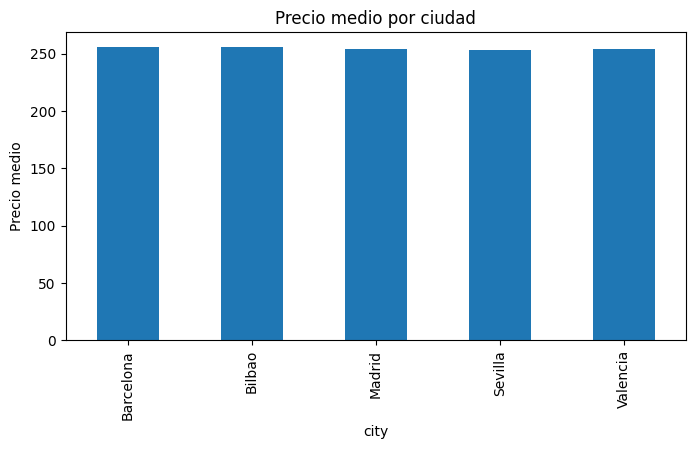

In [ ]:
plot_df.plot(kind="bar", x="city", y="avg_price", legend=False)
plt.ylabel("Precio medio")
plt.title("Precio medio por ciudad")
plt.show()

## Idea importante
`toPandas()` solo conviene usarlo cuando el resultado es pequeño.  
No debe usarse para traer enormes volúmenes de datos al entorno local.

# 27. Ejercicios propuestos

## Ejercicio 1
Selecciona las columnas `city`, `product` y `price`, y muestra solo las 10 primeras filas.

## Ejercicio 2
Filtra las filas donde:
- `category = "Tecnologia"`
- y `price > 300`

## Ejercicio 3
Crea una columna `final_price` aplicando el descuento.

## Ejercicio 4
Agrupa por `city` y calcula:
- número de ventas
- suma de cantidades
- media de rating

## Ejercicio 5
Escribe una consulta SQL que calcule el precio máximo por categoría.

## Ejercicio 6
Haz un WordCount diferente con RDDs usando frases inventadas por ti.

## Ejercicio 7
Explica con tus palabras:
- qué es una transformación
- qué es una acción
- qué es lazy evaluation

## Ejercicio 8
Crea un pequeño modelo de MLlib con otras reglas para la variable objetivo.

# 28. Preguntas de reflexión

1. ¿Por qué Spark no ejecuta todo inmediatamente?
2. ¿Qué ventaja tiene usar SQL sobre Spark?
3. ¿Para qué sirve entender RDDs si hoy se usan más DataFrames?
4. ¿Qué diferencia hay entre trabajar en local y trabajar en clúster?
5. ¿Cuándo usarías Pandas, cuándo Polars y cuándo Spark?

# 29. Conclusión final

Si te quedas con pocas ideas, que sean estas:

- Spark está pensado para **procesamiento distribuido**.
- Los DataFrames de Spark no son simplemente “Pandas grande”.
- Spark distingue entre **transformaciones** y **acciones**.
- Gran parte de su potencia viene de la **lazy evaluation** y la optimización del plan.
- SQL, DataFrames y RDDs son distintas puertas de entrada al mismo ecosistema.
- MLlib muestra que Spark también puede abarcar machine learning.

Entender estas ideas te da una base muy sólida para seguir avanzando en Big Data.